In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset

In [11]:
(X_train, y_train), (X_test,y_test) = datasets.cifar100.load_data()
X_train.shape

(50000, 32, 32, 3)

In [12]:
X_test.shape

(10000, 32, 32, 3)

In [13]:
y_train.shape

(50000, 1)

In [14]:
y_train[:5]

array([[19],
       [29],
       [ 0],
       [11],
       [ 1]])

In [15]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([19, 29,  0, 11,  1])

In [25]:
classes = ["beaver", "dolphin", "otter", "seal", "whale", "aquarium fish", "flatfish", "ray", "shark", "trout", "orchids", "poppies", "roses", "sunflowers", "tulips", "bottles", "bowls", "cans", "cups", "plates", "apples", "mushrooms", "oranges", "pears", "sweet peppers", "clock", "computer keyboard", "lamp", "telephone", "television", "bed", "chair", "couch", "table", "wardrobe", "bee", "beetle", "butterfly", "caterpillar", "cockroach", "bear", "leopard", "lion", "tiger", "wolf", "bridge", "castle", "house", "road", "skyscraper", "cloud", "forest", "mountain", "plain", "sea", "camel", "cattle", "chimpanzee", "elephant", "kangaroo", "fox", "porcupine", "possum", "raccoon", "skunk", "crab", "lobster", "snail", "spider", "worm", "baby", "boy", "girl", "man", "woman", "crocodile", "dinosaur", "lizard", "snake", "turtle", "hamster", "mouse", "rabbit", "shrew", "squirrel", "maple", "oak", "palm", "pine", "willow", "bicycle", "bus", "motorcycle", "pickup truck", "train", "lawn-mower", "rocket", "streetcar", "tank", "tractor"]

Let's plot some images to see what they are

In [16]:
def plot_sample(X, y, index):
    plt.figure(figsize = (10,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

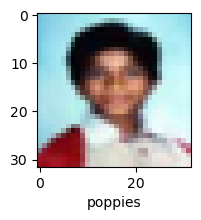

In [27]:
plot_sample(X_train, y_train, 3)

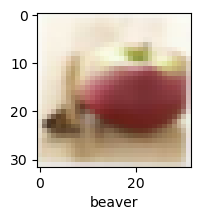

In [28]:
plot_sample(X_train, y_train, 2)

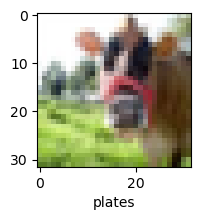

In [29]:
plot_sample(X_train, y_train, 0)

# Normalizing the training data

In [17]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build simple artificial neural network for image classification

In [53]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(100, activation='sigmoid')])
ann.summary()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)               ┃ Output Shape        ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ flatten_3 (Flatten)        │ (None, 3072)        │          0 │
├────────────────────────────┼─────────────────────┼────────────┤
│ dense_8 (Dense)            │ (None, 3000)        │  9,219,000 │
├────────────────────────────┼─────────────────────┼────────────┤
│ dense_9 (Dense)            │ (None, 1000)        │  3,001,000 │
├────────────────────────────┼─────────────────────┼────────────┤
│ dense_10 (Dense)           │ (None, 100)         │    100,100 │
└────────────────────────────┴─────────────────────┴────────────┘

 Total params: 12,320,100 (47.00 MB)

 Trainable params: 12,320,100 (47.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [32]:
ann.fit(X_train, y_train, epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.0820 - loss: 4.1155
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.1413 - loss: 3.7249
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.1724 - loss: 3.5647
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.1909 - loss: 3.4576
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.2065 - loss: 3.3695
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.2210 - loss: 3.2903
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.2319 - loss: 3.2216
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.2465 - loss: 3.1557
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.2596 - loss: 3.0937
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.2699 - loss: 3.0338
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.2798 - loss: 2.9774
Epoch 12

In [18]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("CNN Classification Report: \n", classification_report(y_test, y_pred_classes, target_names=classes))

NameError: name 'ann' is not defined

# Now let us build a convolutional neural network to train our images

In [19]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
cnn = models.Sequential()

cnn.add(Conv2D(32,(3,3),padding='same',activation='relu',kernel_regularizer=l2(1e-4),input_shape=(32,32,3)))
cnn.add(BatchNormalization())
cnn.add(Conv2D(32,(3,3),activation='relu',kernel_regularizer=l2(1e-4)))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D())

cnn.add(Conv2D(64,(3,3),padding='same',activation='relu',kernel_regularizer=l2(1e-4)))
cnn.add(BatchNormalization())
cnn.add(Conv2D(64,(3,3),activation='relu',kernel_regularizer=l2(1e-4)))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D())

cnn.add(Flatten())
cnn.add(Dense(512,activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(100,activation='softmax'))

In [21]:
cnn.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [22]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [23]:
datagen.fit(X_train)
cnn.fit(datagen.flow(X_train,y_train,batch_size=64),
        epochs=150,
        validation_data=(X_test,y_test))

Epoch 1/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 93ms/step - accuracy: 0.0936 - loss: 4.1278 - val_accuracy: 0.1667 - val_loss: 3.5728
Epoch 2/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.1692 - loss: 3.5608 - val_accuracy: 0.2421 - val_loss: 3.1453
Epoch 3/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.2176 - loss: 3.2520 - val_accuracy: 0.2572 - val_loss: 3.0724
Epoch 4/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.2590 - loss: 3.0174 - val_accuracy: 0.3127 - val_loss: 2.7596
Epoch 5/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 89s 113ms/step - accuracy: 0.2937 - loss: 2.8440 - val_accuracy: 0.3468 - val_loss: 2.5855
Epoch 6/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.3209 - loss: 2.6969 - val_accuracy: 0.3695 - val_loss: 2.4702
Epoch 7/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.3467 - loss: 2.5831 - val_accuracy: 0.3941 - val_loss: 2.3490
Epoch 8/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 113ms/step - accuracy: 0.3647 - 

In [24]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5881 - loss: 1.6668


[1.6668287515640259, 0.588100016117096]

In [25]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


array([[2.68136763e-11, 6.99787206e-09, 1.16312694e-04, 3.73396870e-05,
        2.18074765e-05, 3.89551406e-06, 2.80022363e-07, 2.81497819e-06,
        2.45905831e-03, 6.80063204e-06, 5.28936937e-07, 4.46410158e-05,
        5.45105375e-02, 1.47573475e-04, 1.11992824e-06, 1.17837899e-05,
        2.15275704e-05, 1.70257164e-03, 5.73270263e-05, 2.01575617e-07,
        2.63331287e-07, 7.84996610e-06, 1.53150431e-05, 1.16832325e-06,
        8.23399387e-06, 3.01667314e-05, 9.83620339e-07, 1.93907199e-05,
        2.85305248e-07, 1.25691668e-05, 5.65896509e-03, 1.99605282e-07,
        1.63436739e-03, 3.31557726e-06, 6.83426720e-07, 9.60408361e-04,
        5.17254080e-07, 2.37747896e-04, 1.10206805e-04, 6.62441947e-04,
        7.97249028e-04, 1.83497934e-06, 5.37303379e-07, 1.09842119e-07,
        3.33840508e-05, 6.31091052e-06, 7.50220334e-03, 1.58916951e-08,
        1.13323158e-05, 3.23027559e-02, 5.90426453e-07, 4.23674216e-08,
        2.54516697e-09, 3.11522683e-11, 1.25437722e-08, 4.088208

In [26]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(90), np.int64(38), np.int64(24), np.int64(51), np.int64(71)]

In [27]:
y_test[:5]

array([[49],
       [33],
       [72],
       [51],
       [71]])

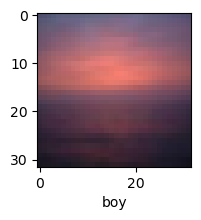

In [87]:
y_test = y_test.reshape(-1,)
plot_sample(X_test, y_test, 4)